In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/Cinema_Audience_Forecasting_challenge/movie_theater_id_relation/movie_theater_id_relation.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/date_info/date_info.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/sample_submission/sample_submission.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_theaters/booknow_theaters.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/cinePOS_booking/cinePOS_booking.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/cinePOS_theaters/cinePOS_theaters.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_visits/booknow_visits.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_booking/booknow_booking.csv


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.svm import LinearSVR
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.feature_selection import SelectKBest, mutual_info_regression

In [3]:
# # from sklearn.dummy import dummyRegressor
# import shutil

# input_path = "/kaggle/input/Cinema_Audience_Forecasting_challenge/sample_submission/sample_submission.csv"

# # Path to output folder where Kaggle expects submission
# output_path = "/kaggle/working/submission.csv"

# # Copy the file
# shutil.copy(input_path, output_path)

b_booking = pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_booking/booknow_booking.csv")
b_theaters = pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_theaters/booknow_theaters.csv")
b_visits = pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_visits/booknow_visits.csv")
c_booking = pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/cinePOS_booking/cinePOS_booking.csv")
c_theaters = pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/cinePOS_theaters/cinePOS_theaters.csv")
date_info = pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/date_info/date_info.csv")
id_rel = pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/movie_theater_id_relation/movie_theater_id_relation.csv")
test = pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/sample_submission/sample_submission.csv")

Milestone 1

In [4]:
print(len(b_visits["book_theater_id"].unique()))
# print(b_theaters.shape)

826


In [5]:
booknow_theaters_clean = b_theaters.dropna(subset=['book_theater_id'])

b_merged = pd.merge(
    b_booking,
    booknow_theaters_clean,
    on="book_theater_id",
    how="left"  # keep all bookings, even if theater info missing
)

print("b_merged shape:", b_merged.shape)

# Check how many bookings got theater details matched
matched = b_merged['theater_type'].notna().sum()
unmatched = b_merged['theater_type'].isna().sum()

print("Matched bookings:", matched)
print("Unmatched bookings:", unmatched)
len(b_merged["book_theater_id"].unique())
distinct_areas = b_merged['theater_area'].dropna().nunique()

print("Distinct theater areas:", distinct_areas)

# If you also want to list them:
print("Theater areas:", b_merged['theater_area'].dropna().unique())

b_merged shape: (68336, 8)
Matched bookings: 36899
Unmatched bookings: 31437
Distinct theater areas: 50
Theater areas: ['Area_017' 'Area_003' 'Area_033' 'Area_008' 'Area_001' 'Area_029'
 'Area_046' 'Area_019' 'Area_015' 'Area_016' 'Area_089' 'Area_094'
 'Area_006' 'Area_030' 'Area_007' 'Area_053' 'Area_002' 'Area_011'
 'Area_020' 'Area_025' 'Area_069' 'Area_021' 'Area_059' 'Area_086'
 'Area_061' 'Area_023' 'Area_009' 'Area_005' 'Area_018' 'Area_074'
 'Area_031' 'Area_066' 'Area_058' 'Area_010' 'Area_027' 'Area_014'
 'Area_024' 'Area_035' 'Area_081' 'Area_082' 'Area_028' 'Area_088'
 'Area_076' 'Area_090' 'Area_092' 'Area_098' 'Area_097' 'Area_042'
 'Area_004' 'Area_077']


In [6]:
# Step 1: join bookings with mapping
step1 = pd.merge(
    c_booking,
    id_rel,
    on="cine_theater_id",
    how="left"
)

# Step 2: add theater info
combined = pd.merge(
    step1,
    c_theaters,
    on="cine_theater_id",
    how="left"
)

# Step 3: Drop cine_theater_id (since test uses book_theater_id instead)
combined = combined.drop(columns=["cine_theater_id"])

print("Combined shape:", combined.shape)
print("Columns:", combined.columns.tolist())

# Check missing
missing_cols = combined.columns[combined.isna().any()].tolist()
print("Missing columns:", ",".join(missing_cols))

combined.isnull().sum()

Combined shape: (1641966, 8)
Columns: ['show_datetime', 'booking_datetime', 'tickets_sold', 'book_theater_id', 'theater_type', 'theater_area', 'latitude', 'longitude']
Missing columns: book_theater_id,theater_type,theater_area,latitude,longitude


show_datetime             0
booking_datetime          0
tickets_sold              0
book_theater_id     1618186
theater_type         942295
theater_area         942295
latitude            1525865
longitude           1525865
dtype: int64

In [7]:
# Get unique book_theater_id from each dataset
booknow_ids = set(b_merged['book_theater_id'].dropna().unique())
cine_ids = set(combined['book_theater_id'].dropna().unique())

# Find common IDs
common_ids = booknow_ids & cine_ids

print("Number of common book_theater_id:", len(common_ids))
print("Example common IDs:", list(common_ids)[:10])


Number of common book_theater_id: 126
Example common IDs: ['book_00317', 'book_00029', 'book_00759', 'book_00042', 'book_00116', 'book_00107', 'book_00365', 'book_00313', 'book_00037', 'book_00155']


In [8]:
# Ensure the column is in datetime format
b_booking['show_datetime'] = pd.to_datetime(b_booking['show_datetime'])

# Find the minimum and maximum dates
min_date = b_booking['show_datetime'].min()
max_date = b_booking['show_datetime'].max()

# Format as dd-mm-yyyy
date_range = f"{min_date.strftime('%d-%m-%Y')} to {max_date.strftime('%d-%m-%Y')}"
print(date_range)


01-01-2023 to 28-02-2024


In [9]:
import pandas as pd

# Load the sample submission
sample = pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/sample_submission/sample_submission.csv")

# Extract date from ID (assumes format: book_<id>_yyyy-mm-dd)
sample['date'] = sample['ID'].str.split('_').str[-1]

# Convert to datetime
sample['date'] = pd.to_datetime(sample['date'])

# Find min and max date
min_date = sample['date'].min()
max_date = sample['date'].max()

# Format as dd-mm-yyyy to dd-mm-yyyy
date_range = f"{min_date.strftime('%d-%m-%Y')} to {max_date.strftime('%d-%m-%Y')}"
print(date_range)


01-03-2024 to 22-04-2024


In [10]:
# Extract book_theater_id from test dataset
sample['book_theater_id'] = sample['ID'].str.rsplit('_', n=1).str[0]

# Get unique IDs from each dataset
test_ids = set(sample['book_theater_id'].unique())
booknow_ids = set(b_merged['book_theater_id'].dropna().unique())
cine_ids = set(combined['book_theater_id'].dropna().unique())

# Find common IDs
common_test_booknow = test_ids & booknow_ids
common_test_cine = test_ids & cine_ids
common_all = test_ids & booknow_ids & cine_ids

print("Common IDs (test & booknow):", len(common_test_booknow))
print("Common IDs (test & cine):", len(common_test_cine))
print("Common IDs (test & booknow & cine):", len(common_all))

# Optional: show some example IDs
print("Example common IDs:", list(common_all)[:10])

# Extract book_theater_id (remove date)
sample['book_theater_id'] = sample['ID'].str.rsplit('_', n=1).str[0]

# Count distinct IDs
total_distinct_ids = sample['book_theater_id'].nunique()
print("Total distinct book_theater_id in test:", total_distinct_ids)



Common IDs (test & booknow): 301
Common IDs (test & cine): 150
Common IDs (test & booknow & cine): 126
Example common IDs: ['book_00317', 'book_00029', 'book_00759', 'book_00042', 'book_00116', 'book_00107', 'book_00365', 'book_00313', 'book_00037', 'book_00155']
Total distinct book_theater_id in test: 827


Milestone 2

In [11]:
# Convert datetime columns safely
b_booking[['booking_datetime', 'show_datetime']] = b_booking[['booking_datetime', 'show_datetime']].apply(
    pd.to_datetime, errors='coerce'
)

# Compare only calendar dates and count matches
same_day_count = (b_booking['booking_datetime'].dt.date == b_booking['show_datetime'].dt.date).sum()

print(f"Total booking records made on the same calendar day as the show's date: {same_day_count}")


Total booking records made on the same calendar day as the show's date: 20433


In [12]:
date_info['show_date'] = pd.to_datetime(date_info['show_date'], errors='coerce')

# Count unique Year-Month combinations
unique_months_count = date_info['show_date'].dt.to_period('M').nunique(dropna=True)

# Print result
print(f"The number of unique calendar months (e.g., Jan 2023) in the 'show_date' column is: {unique_months_count}")

The number of unique calendar months (e.g., Jan 2023) in the 'show_date' column is: 18


In [13]:
# Convert booking datetime safely
b_booking['booking_datetime'] = pd.to_datetime(b_booking['booking_datetime'], errors='coerce')

# Extract day of week (Monday=0, Sunday=6)
sunday_bookings = (b_booking['booking_datetime'].dt.dayofweek == 6).sum()

# Calculate percentage
percentage_sunday = sunday_bookings / len(b_booking) * 100

# Print result
print(f"Percentage of bookings made on a Sunday: {percentage_sunday:.2f}%")


Percentage of bookings made on a Sunday: 13.32%


In [14]:
imputation_value = b_theaters.loc[
    b_theaters['theater_type'] == 'Drama', 'latitude'
].mean()

print(f"Imputation value for missing latitude (Drama theaters mean): {imputation_value:.6f}")

Imputation value for missing latitude (Drama theaters mean): 23.000903


In [15]:
# Compute range of latitude (max - min)
lat_range = b_theaters['latitude'].max() - b_theaters['latitude'].min()

# Print result rounded to 4 decimal places
print(f"Range of latitude values: {lat_range:.4f}")

Range of latitude values: 4.3235


Milestone 3

In [16]:
b_visits['show_date'] = pd.to_datetime(b_visits['show_date'], errors='coerce')

b_visits['day'] = b_visits['show_date'].dt.day
b_visits['month'] = b_visits['show_date'].dt.month
b_visits['year'] = b_visits['show_date'].dt.year
b_visits['dayofyear'] = b_visits['show_date'].dt.dayofyear

# b_visits = b_visits.drop('show_date', axis=1)

In [17]:
X = b_visits.drop('audience_count', axis=1)
y = b_visits['audience_count']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape
# b_visits.head

(171236, 6)

In [18]:
# X_train.dtypes
numerical_cols = X.select_dtypes(include=['int64', 'float64', 'int32']).columns
categorical_cols = X.select_dtypes(include=['object', 'category']).columns
# print(numerical_cols)
num_transformer = MinMaxScaler()
cat_transformer = OneHotEncoder(handle_unknown='ignore')
# print(categorical_cols)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, numerical_cols),
        ('cat', cat_transformer, categorical_cols)
    ]
)

# Fit on training data
preprocessor.fit(X_train)

# Transform both train and test data
X_train_transformed = preprocessor.transform(X_train)
X_test_transformed = preprocessor.transform(X_test)



In [19]:
model = LinearSVR()
model.fit(X_train_transformed, y_train)

# 8️⃣ Predict and evaluate
y_pred = model.predict(X_test_transformed)
r2 = r2_score(y_test, y_pred)

# 9️⃣ Print R² score rounded to 3 decimal places
print("R² score on test dataset:", round(r2, 3))

R² score on test dataset: 0.386


In [20]:
svd = TruncatedSVD(n_components=4, random_state=42)
X_train_svd = svd.fit_transform(X_train_transformed)
X_test_svd = svd.transform(X_test_transformed)

model = LinearSVR(random_state=42, max_iter=10000)
model.fit(X_train_svd, y_train)

# 9️⃣ Compute Mean Absolute Error on training data
y_train_pred = model.predict(X_train_svd)
mae = mean_absolute_error(y_train, y_train_pred)

# 🔟 Print MAE rounded to 3 decimals
print("Mean Absolute Error on training data:", round(mae, 3))
y_test_pred = model.predict(X_test_svd)
r2 = r2_score(y_test, y_test_pred)

print("R² score on test data:", round(r2, 3))

Mean Absolute Error on training data: 23.896
R² score on test data: -0.053


In [21]:
# X_processed = preprocessor.fit_transform(X)
# X_processed.shape
# # 6️⃣ Apply SelectKBest with mutual_info_regression
# selector = SelectKBest(score_func=mutual_info_regression, k=2)
# selector.fit(X_processed, y)

# # 7️⃣ Get feature scores
# scores = selector.scores_

# # 8️⃣ Find the maximum score
# max_score = scores.max()

# print("Maximum SelectKBest score:", round(max_score, 3))

In [22]:
# mean_score = scores.mean()

# print("Mean of SelectKBest scores:", round(mean_score, 3))

**Final Project Pipeline**

**Imports and Setup**

In [23]:
import warnings
warnings.filterwarnings('ignore')

# Standard & Math Libraries
import random
import numpy as np
import pandas as pd

# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Models
import lightgbm as lgb
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.ensemble import RandomForestRegressor

# Sklearn Utilities & Metrics
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import r2_score, mean_squared_error

# --- EDA STYLE ---
plt.style.use('fivethirtyeight')

print("--- CINEMA AUDIENCE FORECASTING ---")
print("Libraries imported and warnings suppressed.")

--- CINEMA AUDIENCE FORECASTING ---
Libraries imported and warnings suppressed.


**Load Data and Test Set**

In [24]:
# --- 0) Load Data & Mark Labeled/Test ---
print("Step 0: Loading and Marking Data...")

# Load all provided files using Kaggle paths
b_visits = pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_visits/booknow_visits.csv")
test = pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/sample_submission/sample_submission.csv")
b_theaters = pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_theaters/booknow_theaters.csv")
id_rel = pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/movie_theater_id_relation/movie_theater_id_relation.csv")
c_theaters = pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/cinePOS_theaters/cinePOS_theaters.csv")
date_info = pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/date_info/date_info.csv")


# Create definitive test keys from sample_submission
sub_keys_df = test.copy()
parts = sub_keys_df["ID"].str.rsplit("_", n=1, expand=True)
sub_keys_df["book_theater_id"] = parts[0]
sub_keys_df["show_date"] = pd.to_datetime(parts[1])
test_keys = sub_keys_df[["book_theater_id", "show_date"]].drop_duplicates()
test_keys["_is_kaggle_test"] = True
expected_test_len = len(test_keys)
print(f"Definitive test key lookup created with {expected_test_len} rows.")


b_visits['_is_labeled'] = True
test['_is_labeled'] = False

parts = test["ID"].str.rsplit("_", n=1, expand=True)
test["book_theater_id"] = parts[0]
test["show_date"] = pd.to_datetime(parts[1])
test["audience_count"] = np.nan
test = test.drop(columns=['ID'])

b_visits["show_date"] = pd.to_datetime(b_visits["show_date"])

full_df = pd.concat([b_visits, test], ignore_index=True)

full_df = full_df.groupby(["book_theater_id", "show_date"], as_index=False).agg({
    'audience_count': lambda x: x.sum(min_count=1),
    '_is_labeled': 'first'
})
print("Data loaded.")
print(f"full_df shape: {full_df.shape}")

Step 0: Loading and Marking Data...
Definitive test key lookup created with 38062 rows.
Data loaded.
full_df shape: (251933, 4)


**Reindex Data per Theater**

In [25]:
print("Step 1: Reindexing per theater")

def reindex_daily_safe(g):
    bt_id = g.name
    g = g[['show_date','audience_count','_is_labeled']].copy()
    idx = pd.date_range(g['show_date'].min(), g['show_date'].max(), freq='D')
    g = g.set_index('show_date').reindex(idx)
    g.index.name = 'show_date'
    g['book_theater_id'] = bt_id
    g['_is_gap'] = g['_is_labeled'].isna()
    mask_labeled = g['_is_labeled'] == True
    g.loc[mask_labeled, 'audience_count'] = g.loc[mask_labeled, 'audience_count'].fillna(0)
    return g.reset_index()

full_df = (full_df
    .sort_values(['book_theater_id','show_date'])
    .groupby('book_theater_id', group_keys=True)
    [['show_date','audience_count','_is_labeled']]
    .apply(reindex_daily_safe)
    .reset_index(drop=True)
)

full_df['_is_labeled'] = full_df['_is_labeled'].fillna(False).astype(bool)
print("Reindexing complete. _is_labeled normalized.")
print(f"full_df shape after reindexing: {full_df.shape}")

Step 1: Reindexing per theater
Reindexing complete. _is_labeled normalized.
full_df shape after reindexing: (296797, 5)


**Feature Engineering** (Static Merges & Date)

In [26]:
print("Step 2: Merging static & holiday features")

full_df = pd.merge(full_df, b_theaters, on="book_theater_id", how="left")
full_df = pd.merge(full_df, id_rel, on="book_theater_id", how="left")
full_df = pd.merge(full_df, c_theaters, on="cine_theater_id", how="left", suffixes=('_booknow', '_cinepos'))

date_info['show_date'] = pd.to_datetime(date_info['show_date'])
full_df = pd.merge(full_df, date_info, on="show_date", how="left")

for col in ['theater_type_booknow', 'theater_area_booknow', 'theater_type_cinepos', 'theater_area_cinepos']:
    if col in full_df.columns:
        full_df[col] = full_df[col].fillna('Unknown')

for col in ['is_holiday', 'is_event', 'is_school_vacation']: 
    if col in full_df.columns:
        full_df[col] = full_df[col].fillna(0).astype('int8')
print("Merges complete.")

# Date Features 
print("Step 3: Creating date features...")

# Basic calendar parts
full_df['day_of_month'] = full_df['show_date'].dt.day.astype('int16')
full_df['day_of_year']  = full_df['show_date'].dt.dayofyear.astype('int16')
full_df['month']        = full_df['show_date'].dt.month.astype('int8')
full_df['quarter']      = full_df['show_date'].dt.quarter.astype('int8')

# Weekday mapping
if 'day_of_week' in full_df.columns:
    _map = {'Monday':0,'Tuesday':1,'Wednesday':2,'Thursday':3,'Friday':4,'Saturday':5,'Sunday':6}
    full_df['weekday'] = full_df['day_of_week'].map(_map)
else:
    full_df['weekday'] = full_df['show_date'].dt.weekday

full_df['weekday']    = full_df['weekday'].astype('int8')
full_df['is_weekend'] = (full_df['weekday'] >= 5).astype('int8')

# ISO week number
iso = full_df['show_date'].dt.isocalendar()
full_df['week_of_year'] = iso.week.astype('int16')

print("Date features created.")
print(f"full_df shape: {full_df.shape}")

Step 2: Merging static & holiday features
Merges complete.
Step 3: Creating date features...
Date features created.
full_df shape: (296797, 22)


**EDA - Data Availability and Gaps**

EDA 1: Visualizing Data Availability


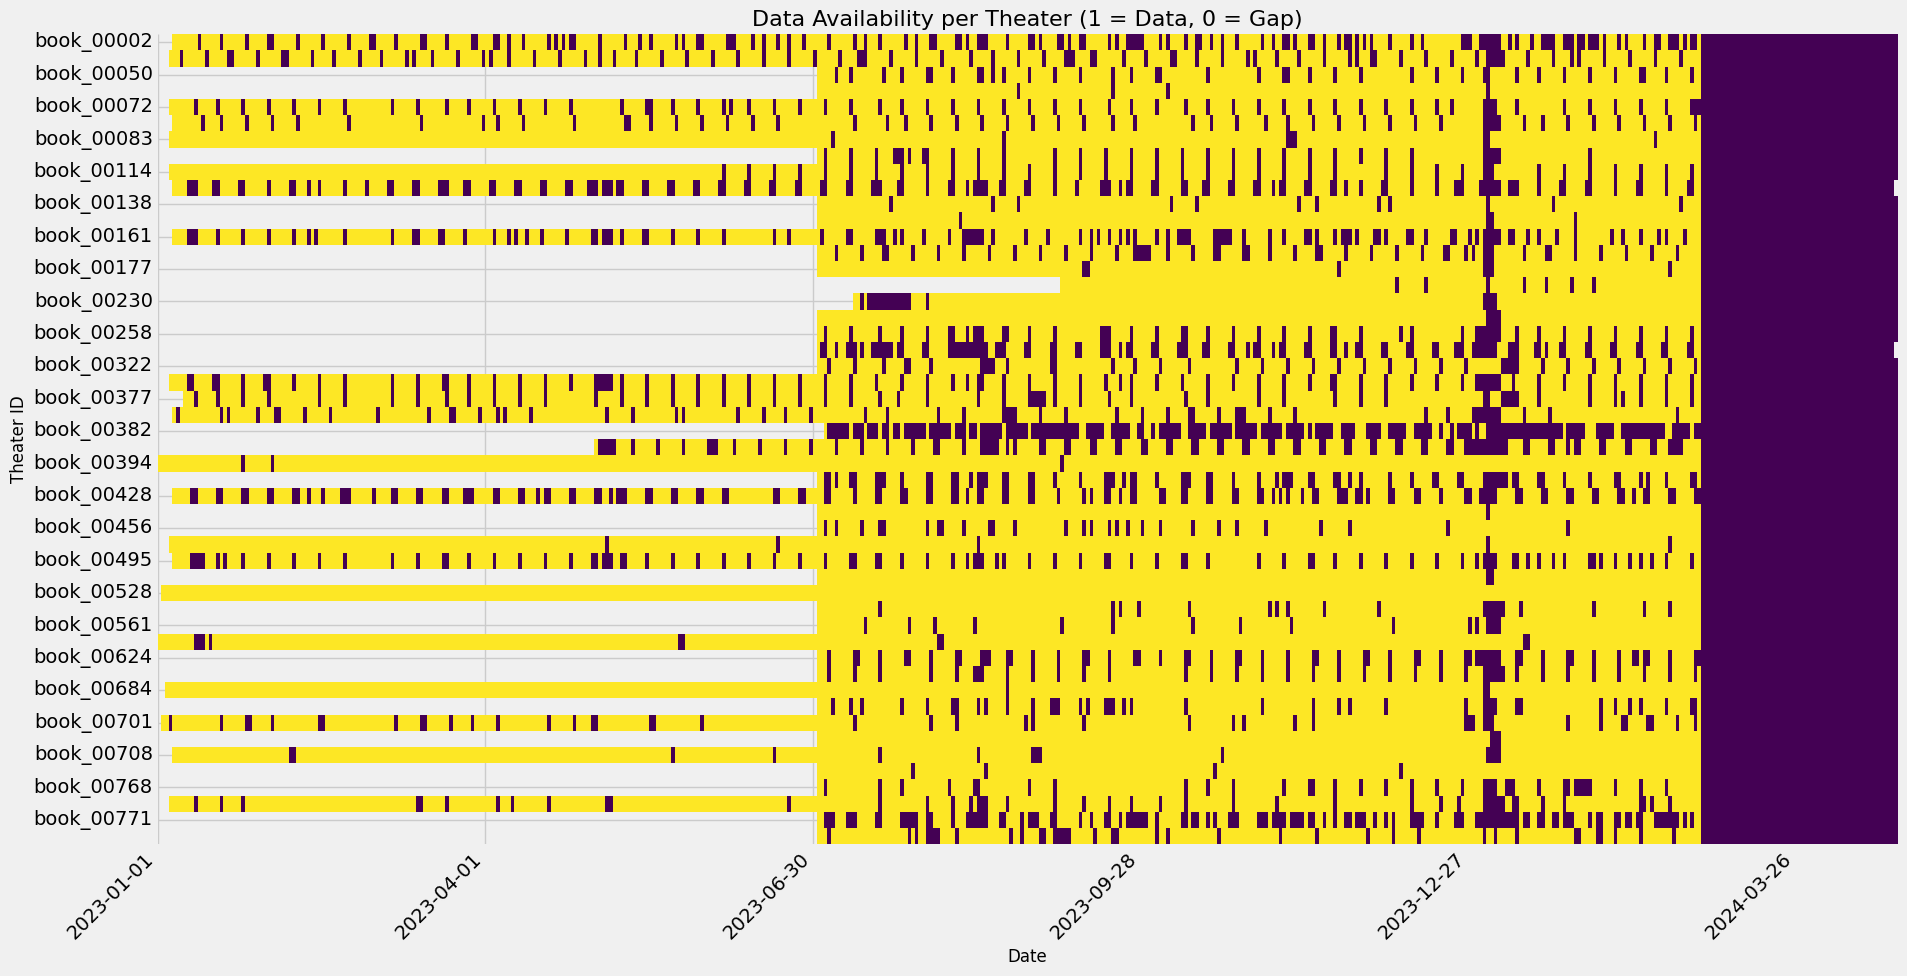

In [27]:
print("EDA 1: Visualizing Data Availability")

# Sample theaters to keep the plot readable
all_theaters = full_df['book_theater_id'].unique()
sample_theaters = np.random.choice(all_theaters, min(len(all_theaters), 50), replace=False)

plot_df = full_df[full_df['book_theater_id'].isin(sample_theaters)].copy()

# 1 = Labeled Data, 0 = Gap
plot_df['plot_status'] = plot_df['_is_labeled'].astype(int)

try:
    # Pivot for heatmap
    heatmap_data = plot_df.pivot(index='book_theater_id', columns='show_date', values='plot_status')

    plt.figure(figsize=(20, 10))
    ax = sns.heatmap(heatmap_data, cbar=False, cmap='viridis')
    
    plt.title('Data Availability per Theater (1 = Data, 0 = Gap)', fontsize=16)
    plt.xlabel('Date', fontsize=12)
    
    plt.ylabel('Theater ID', fontsize=12) 
    
    date_labels = heatmap_data.columns
    total_days = len(date_labels)
    tick_interval = 90 
    tick_positions = np.arange(0, total_days, tick_interval)
    tick_labels = [date_labels[i].strftime('%Y-%m-%d') for i in tick_positions]

    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels, rotation=45, ha='right')
    
    plt.show()

except Exception as e:
    print(f"Could not pivot data for heatmap: {e}")

**Heatmap:** To find audience_count being present on that date in the theaters, purple being missing and yellow is present

**EDA - Target Variable Distribution**

EDA 2: Target Variable Distribution


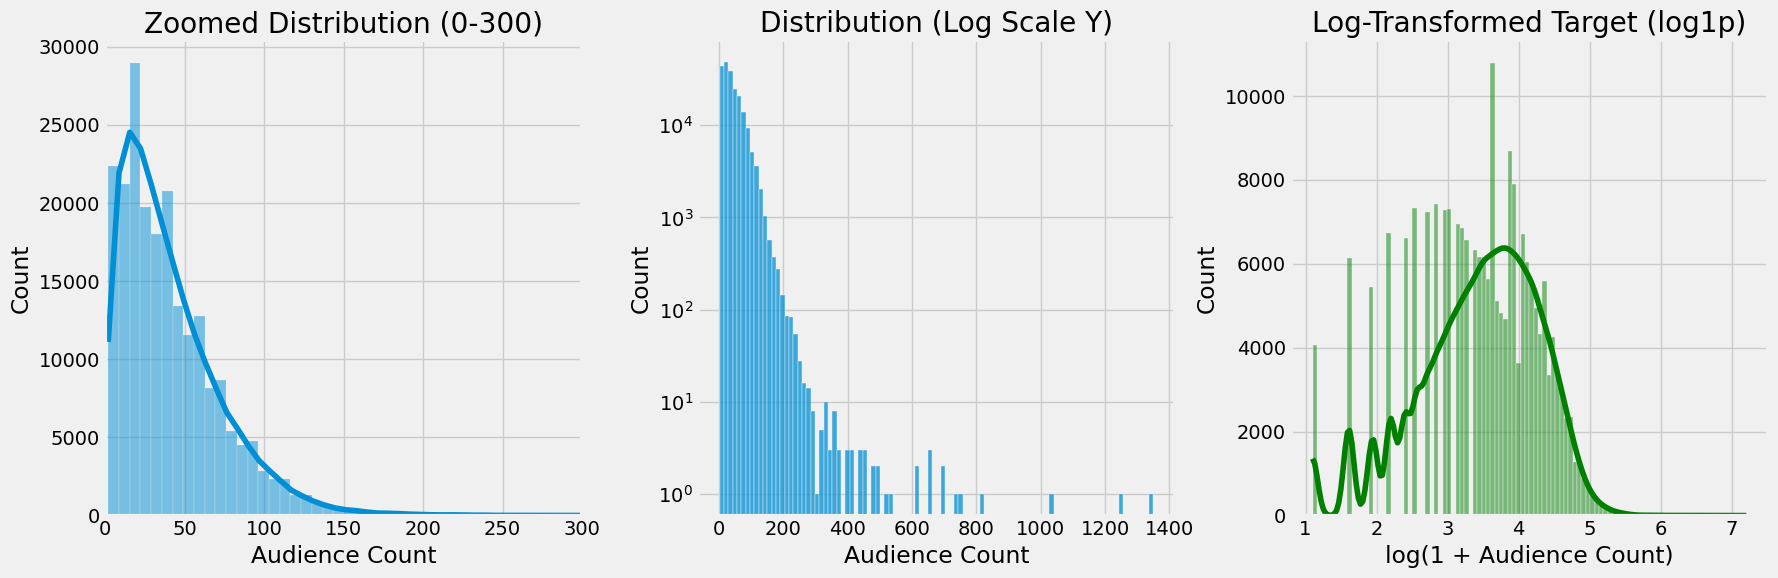

Percentage of Labeled Days with Zero Audience: 0.00%
Mean Audience (on labeled days): 41.65
Median Audience (on labeled days): 34.00


In [28]:
print("EDA 2: Target Variable Distribution")

# Plot only the data we actually have labels for
labeled_data = full_df[full_df['_is_labeled'] == True]['audience_count']

plt.figure(figsize=(18, 6))

# 1. Zoomed-in Histogram
plt.subplot(1, 3, 1)
sns.histplot(labeled_data, bins=200, kde=True)
plt.xlim(0, 300)  # <--- The "Zoom"
plt.title('Zoomed Distribution (0-300)')
plt.xlabel('Audience Count')

# 2. Log Scale Y-Axis (To see the outliers/tail)
plt.subplot(1, 3, 2)
sns.histplot(labeled_data, bins=100, kde=False)
plt.yscale('log') # <--- The "Scale" (Y-axis)
plt.title('Distribution (Log Scale Y)')
plt.xlabel('Audience Count')

# 3. Log-Transformed Feature (Target)
plt.subplot(1, 3, 3)
sns.histplot(labeled_data.apply(np.log1p), bins=100, kde=True, color='green')
plt.title('Log-Transformed Target (log1p)')
plt.xlabel('log(1 + Audience Count)')

plt.tight_layout()
plt.show()

# Print key stats
zero_percentage = (labeled_data == 0).mean() * 100
print(f"Percentage of Labeled Days with Zero Audience: {zero_percentage:.2f}%")
print(f"Mean Audience (on labeled days): {labeled_data.mean():.2f}")
print(f"Median Audience (on labeled days): {labeled_data.median():.2f}")


* Insights: The data is highly skewed with a long tail and a significant number of zeros.
* This justifies using a Tweedie objective in our model.



**EDA - Temporal Patterns (Weekly & Monthly)**

EDA 3: Temporal Patterns


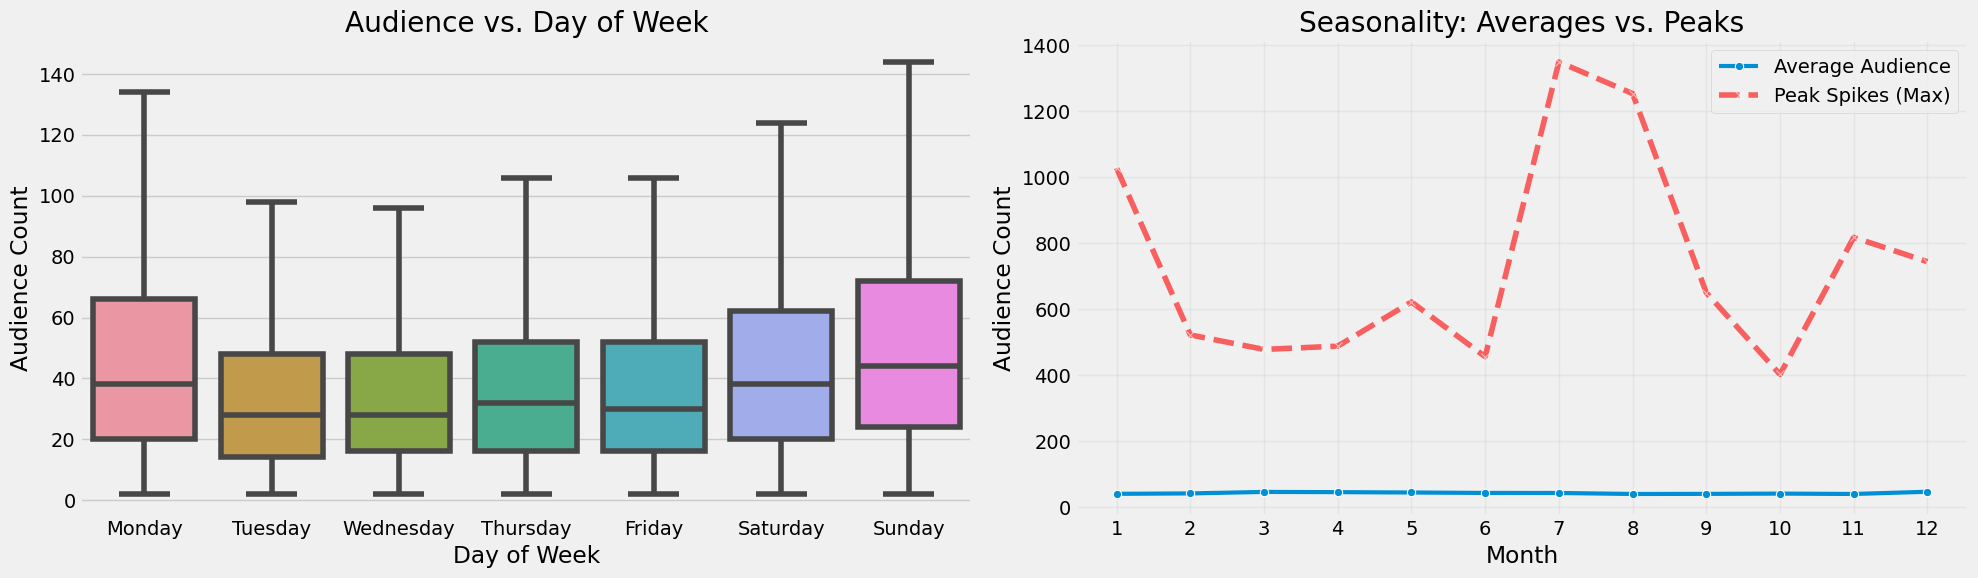

In [29]:
print("EDA 3: Temporal Patterns")

# Use only labeled data
plot_df = full_df[full_df['_is_labeled'] == True].copy()

plt.figure(figsize=(20, 6))

# Plot 1: Day of Week
plt.subplot(1, 2, 1)
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_map = {0:'Monday', 1:'Tuesday', 2:'Wednesday', 3:'Thursday', 4:'Friday', 5:'Saturday', 6:'Sunday'}
plot_df['weekday_name'] = plot_df['weekday'].map(day_map)

sns.boxplot(data=plot_df, x='weekday_name', y='audience_count', order=weekday_order, showfliers=False)
plt.title('Audience vs. Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Audience Count')

# Plot 2: Monthly Seasonality
plt.subplot(1, 2, 2)

# 1. Calculate stats per month
monthly_stats = plot_df.groupby('month')['audience_count'].agg(['mean', 'max']).reset_index()

# 2. Plot Average Trend
sns.lineplot(data=monthly_stats, x='month', y='mean', marker='o', linewidth=3, label='Average Audience')

# 3. Plot Peaks (Spikes)
# Use a secondary y-axis usually if scales differ, but here we want to see the gap
sns.lineplot(data=monthly_stats, x='month', y='max', marker='x', color='red', linestyle='--', alpha=0.6, label='Peak Spikes (Max)')

plt.title('Seasonality: Averages vs. Peaks')
plt.xlabel('Month')
plt.ylabel('Audience Count')
plt.xticks(range(1, 13)) # Ensure all 12 months show
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()


* Insights: A very strong weekly pattern is visible (weekends are highest).
* This is our primary justification for creating `lag_7`, `lag_14`, and `roll_mean_7` features.
* A clear monthly seasonality also exists, justifying the `month` feature.


**EDA - Overall Audience Trend**

EDA 4: Overall Audience Trend Over Time


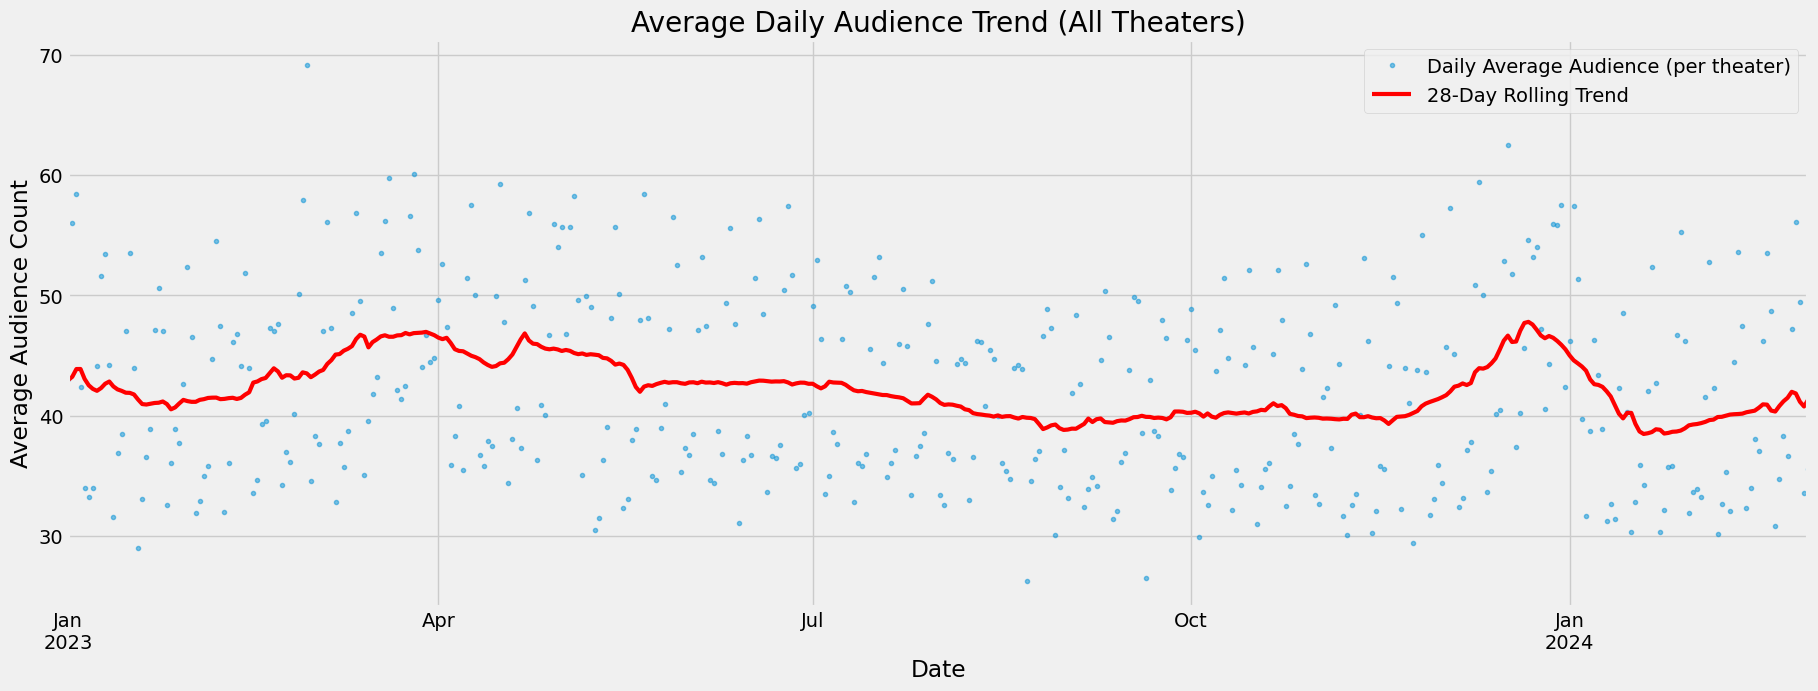

In [30]:
print("EDA 4: Overall Audience Trend Over Time")

# Use only labeled data
plot_df = full_df[full_df['_is_labeled'] == True].copy()

# Aggregate audience per day (mean per theater)
# This normalizes for the number of theaters reporting each day
daily_avg_audience = plot_df.groupby('show_date')['audience_count'].mean()

# Calculate a 28-day rolling average to see the trend clearly
# We use center=True to make the trend line align with the data
daily_avg_audience_trend = daily_avg_audience.rolling(28, min_periods=7, center=True).mean()

plt.figure(figsize=(20, 7))
# Plot the noisy daily data as small points
daily_avg_audience.plot(label='Daily Average Audience (per theater)', alpha=0.5, style='.')
# Plot the smoothed trend line
daily_avg_audience_trend.plot(label='28-Day Rolling Trend', color='red', linewidth=3)

plt.title('Average Daily Audience Trend (All Theaters)')
plt.xlabel('Date')
plt.ylabel('Average Audience Count')
plt.legend()
plt.show()


* Insights: This plot shows the long-term trend and seasonality of cinema attendance.
* You can see seasonal peaks/valleys and any long-term growth or decline.
* This justifies using time-based features like `day_of_year` and `month` to capture this seasonality.


**EDA - Static Feature Impact (Theaters)**

EDA 5: Static Feature Impact (Theater Properties) - Sorted by Frequency


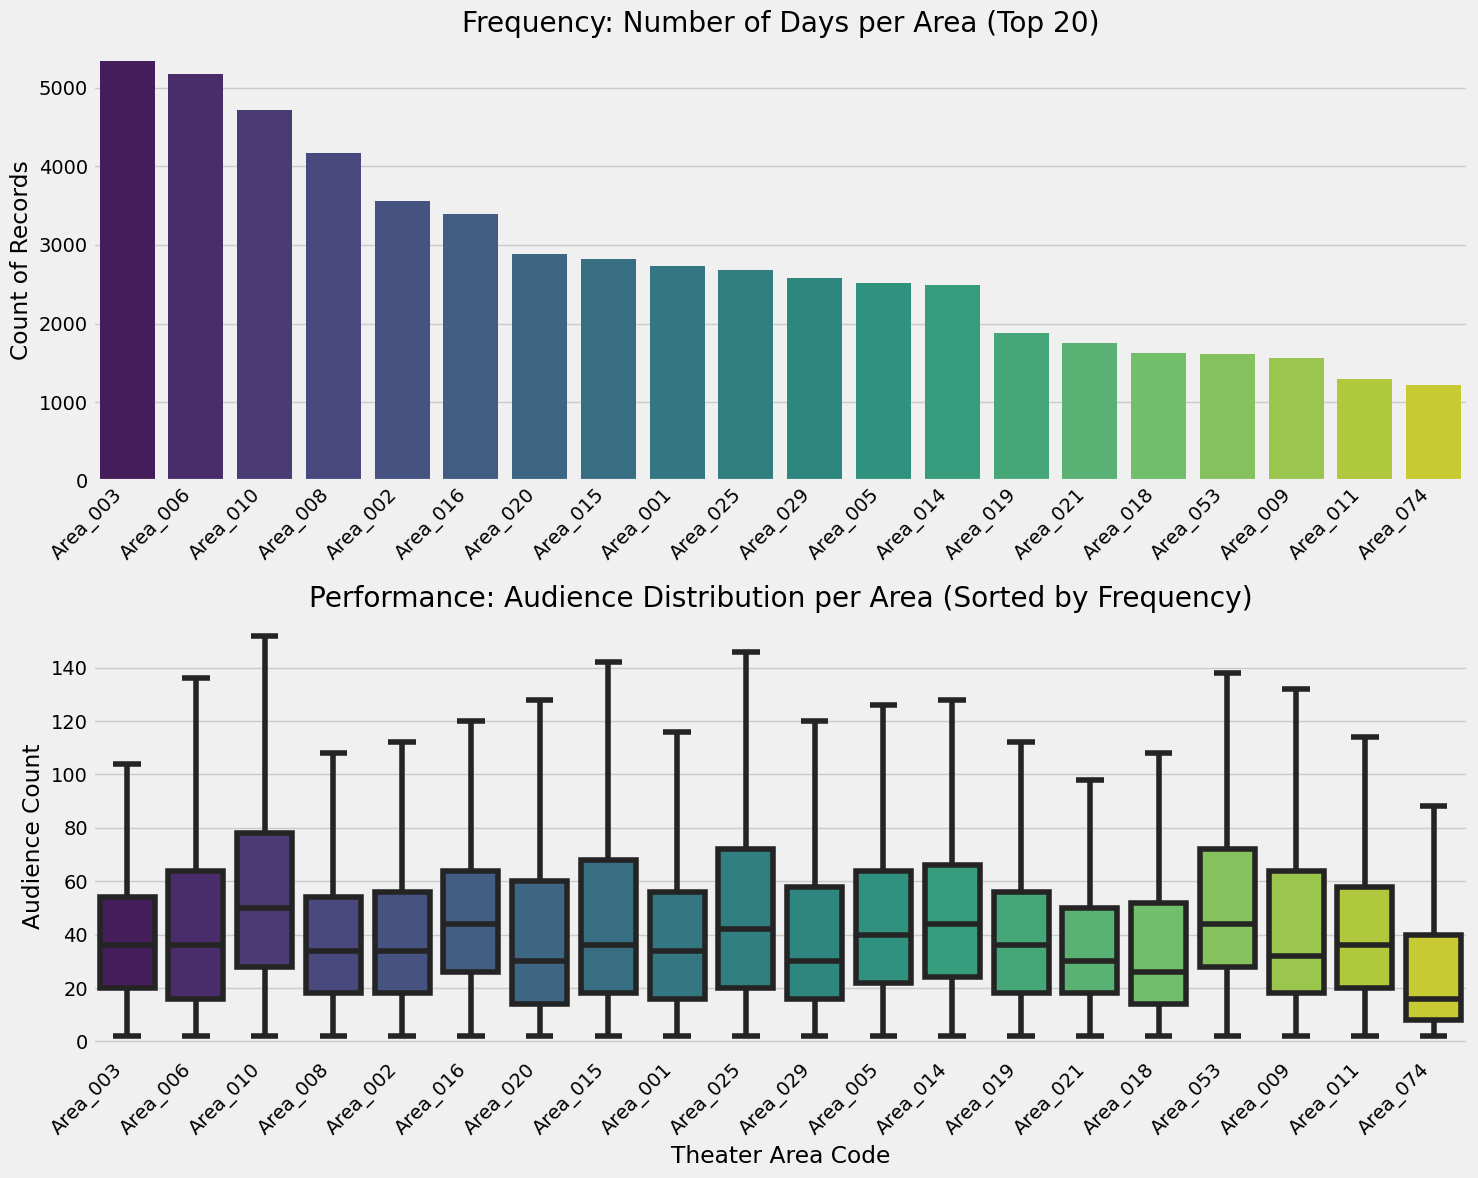

In [31]:
print("EDA 5: Static Feature Impact (Theater Properties) - Sorted by Frequency")

# Use only labeled data and exclude Unknown
plot_df = full_df[full_df['_is_labeled'] == True].copy()
plot_df['theater_area_code'] = plot_df['theater_area_booknow'].apply(
    lambda x: x.split('-')[0] if '-' in str(x) else x
)
plot_df = plot_df[plot_df['theater_area_code'] != 'Unknown']

# 1. Identify Top N areas
top_n_areas = 20 
top_areas_counts = plot_df['theater_area_code'].value_counts().nlargest(top_n_areas)
top_areas_list = top_areas_counts.index.tolist()

# 2. Filter Data
plot_df_filtered = plot_df[plot_df['theater_area_code'].isin(top_areas_list)].copy()

# 3. Define the shared order (Sorted by Count High -> Low)
shared_order = top_areas_list

# --- Stack plots vertically with shared X-axis order ---
plt.figure(figsize=(15, 12)) 

# Plot 1 (Top): Count of Days
plt.subplot(2, 1, 1) 
sns.countplot(data=plot_df_filtered, x='theater_area_code',
              order=shared_order, palette='viridis') # Added palette for visual distinction
plt.title(f'Frequency: Number of Days per Area (Top {top_n_areas})')
plt.xlabel('') # Hide x-label to reduce clutter
plt.ylabel('Count of Records')
plt.xticks(rotation=45, ha='right') 

# Plot 2 (Bottom): Audience Distribution (Same Order)
plt.subplot(2, 1, 2) 
sns.boxplot(data=plot_df_filtered, x='theater_area_code', y='audience_count', 
            showfliers=False, order=shared_order, palette='viridis')
plt.title(f'Performance: Audience Distribution per Area (Sorted by Frequency)')
plt.xlabel('Theater Area Code')
plt.ylabel('Audience Count')
plt.xticks(rotation=45, ha='right') 

plt.tight_layout() 
plt.show()

**Feature Engineering** (Time-Series Lags & Rolls)

In [32]:
print("Step 4: Creating time-series features...")
aud_raw = full_df['audience_count'].where(~full_df['_is_gap'], np.nan)
full_df = full_df.sort_values(['book_theater_id','show_date'])

g_filled = full_df.groupby('book_theater_id')['audience_count']

# Base Lags
full_df['lag_7']  = g_filled.shift(7)
full_df['lag_14'] = g_filled.shift(14)
full_df['lag_28'] = g_filled.shift(28) 
full_df['lag7_avail'] = full_df['lag_7'].notna().astype('int8') # For blend

# Rolls
full_df['roll_mean_7']  = g_filled.shift(1).rolling(7,  min_periods=1).mean()
full_df['roll_mean_14'] = g_filled.shift(1).rolling(14, min_periods=1).mean()
full_df['roll_std_7']   = g_filled.shift(1).rolling(7,  min_periods=2).std()

# EWMs (on NaN-preserving data)
g_raw = full_df.assign(aud_raw=aud_raw).groupby('book_theater_id')['aud_raw']
full_df['ewm_mean_7'] = (
    g_raw.apply(lambda s: s.shift(1).ewm(span=7, adjust=False, ignore_na=True).mean())
         .reset_index(level=0, drop=True)
)
full_df['ewm_mean_14'] = (
    g_raw.apply(lambda s: s.shift(1).ewm(span=14, adjust=False, ignore_na=True).mean())
         .reset_index(level=0, drop=True)
)

ts_features_to_impute = [
    'lag_7', 'lag_14', 'lag_28',
    'roll_mean_7', 'roll_mean_14', 'roll_std_7',
    'ewm_mean_7', 'ewm_mean_14',
]
print("Time-series features created.")

Step 4: Creating time-series features...
Time-series features created.


**Feature Engineering** (Expanding Stats & Interactions)

In [33]:
print("Step 4b: Creating expanding stats")
full_df = full_df.sort_values(['book_theater_id','show_date']).copy()
# Use only past labeled values for stats
full_df['aud_for_stats'] = np.where(full_df['_is_labeled'], full_df['audience_count'], np.nan)

# Per-theater expanding mean of *all days* (level baseline)
print("exp_mean_all")
full_df['exp_mean_all'] = (
    full_df.groupby('book_theater_id')['aud_for_stats']
           .apply(lambda s: s.shift(1).expanding(min_periods=3).mean())
           .reset_index(level=0, drop=True)
)

# Per-theater, per-weekday expanding mean (weekly baseline)
print("exp_mean_wd")
full_df['exp_mean_wd'] = (
    full_df.groupby(['book_theater_id','weekday'])['aud_for_stats']
           .apply(lambda s: s.shift(1).expanding(min_periods=2).mean())
           .reset_index(level=[0,1], drop=True)
)

# Days since last nonzero (recency of demand)
print("... days_since_last_nz")
is_nz = (full_df['_is_labeled'] & (full_df['audience_count'] > 0))
last_nz_date_col = full_df['show_date'].where(is_nz, pd.NaT)

full_df['last_nz_date'] = (
    last_nz_date_col.groupby(full_df['book_theater_id']).ffill()
)
full_df['days_since_last_nz'] = (
    (full_df['show_date'] - full_df['last_nz_date']).dt.days
      .fillna(999).astype('int16')
)

# Share of nonzero in last 7 labeled days (stability)
print("... nz_ratio_7")
nz_hist = (
    full_df.assign(aud_hist=np.where(full_df['_is_labeled'], full_df['audience_count'], np.nan))
           .groupby('book_theater_id')['aud_hist']
           .apply(lambda s: (s.shift(1) > 0).astype(float).rolling(7, min_periods=3).mean())
           .reset_index(level=0, drop=True)
)
full_df['nz_ratio_7'] = nz_hist.astype('float64')


# Simple holiday/weekend interactions
col_hol = full_df['is_holiday'] == 1 if 'is_holiday' in full_df.columns else pd.Series(False, index=full_df.index)
col_evt = full_df['is_event'] == 1 if 'is_event' in full_df.columns else pd.Series(False, index=full_df.index)

full_df['is_hol_or_event'] = (col_hol | col_evt).astype('int8')
full_df['weekend_x_hol'] = (full_df['is_weekend'] * full_df['is_hol_or_event']).astype('int8')

# Fill new numeric features
new_expanding_feats = ['exp_mean_all','exp_mean_wd','nz_ratio_7']

# This prevents errors if you re-run the cell
for feat in new_expanding_feats:
    if feat not in ts_features_to_impute:
        ts_features_to_impute.append(feat)

# [FIX] Keep NaNs for most features, which LightGBM handles.
full_df[ts_features_to_impute] = full_df[ts_features_to_impute].astype('float64')
# Only fill std with 0.0, as NaN std is meaningless
full_df['roll_std_7'] = full_df['roll_std_7'].fillna(0.0) 
print("Expanding stats created and TS NaNs preserved.")

Step 4b: Creating expanding stats
exp_mean_all
exp_mean_wd
... days_since_last_nz
... nz_ratio_7
Expanding stats created and TS NaNs preserved.


**EDA - Lag Feature Correlation**

EDA 6 (Alternative): Simple Regression Plot


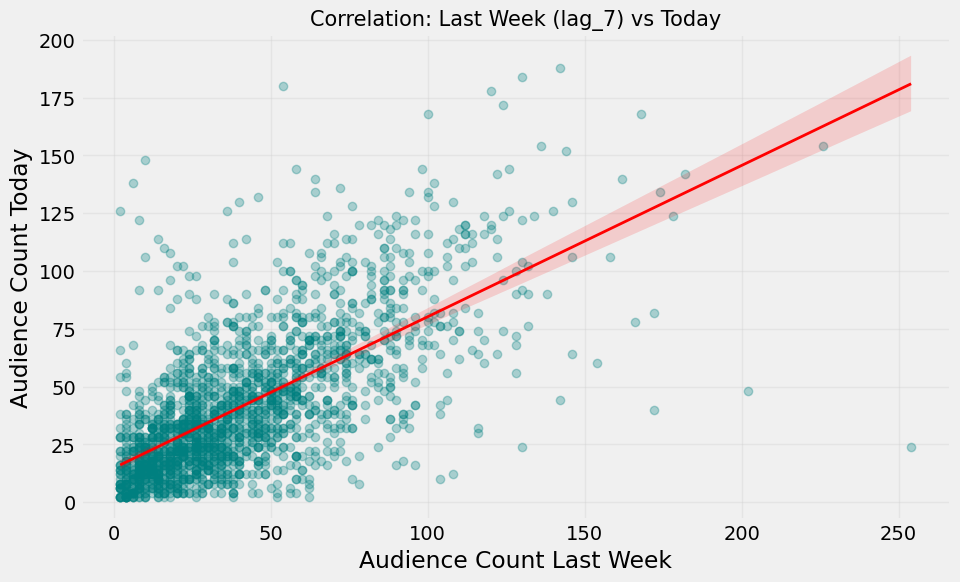

Pearson Correlation Score: 0.6113


In [34]:
print("EDA 6 (Alternative): Simple Regression Plot")

# Use labeled data
plot_df = full_df[full_df['_is_labeled'] == True].copy()
plot_df.dropna(subset=['lag_7', 'audience_count'], inplace=True)

# Filter out the massive pile of (0,0) points just for the plot clarity
# (We keep them for the model, but they hide the visual trend)
plot_filtered = plot_df[(plot_df['lag_7'] > 0) | (plot_df['audience_count'] > 0)]

# Sample 2000 points for a clean scatter plot
sample_data = plot_filtered.sample(n=2000, random_state=42)

plt.figure(figsize=(10, 6))

# sns.regplot draws the scatter AND the trend line automatically
sns.regplot(
    data=sample_data, 
    x='lag_7', 
    y='audience_count', 
    scatter_kws={'alpha': 0.3, 'color': 'teal'}, # alpha makes dots transparent so you see stacking
    line_kws={'color': 'red', 'linewidth': 2}    # The trend line
)

plt.title('Correlation: Last Week (lag_7) vs Today', fontsize=15)
plt.xlabel('Audience Count Last Week')
plt.ylabel('Audience Count Today')
plt.grid(True, alpha=0.3)
plt.show()

corr = plot_df['lag_7'].corr(plot_df['audience_count'])
print(f"Pearson Correlation Score: {corr:.4f}")

**EDA - Rolling Mean & Recency Correlation**

EDA 7: Rolling Mean & Stability Feature Validation (With Correlation Scores)


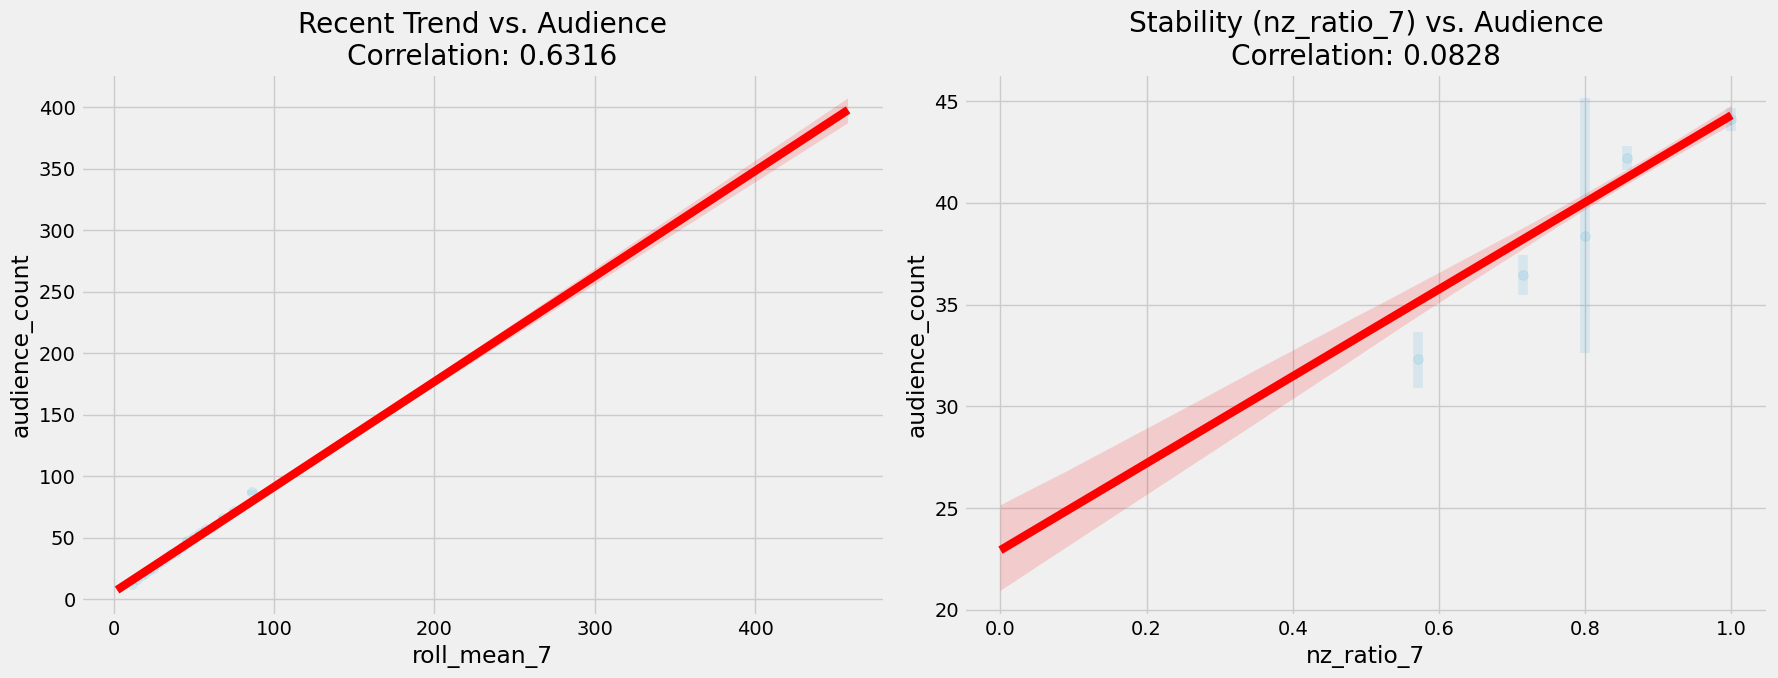


Score Interpretation:
1. Recent Trend (Rolling Mean) Correlation: 0.6316 (Closer to 1.0 is better)
2. Stability (Non-Zero Ratio) Correlation:  0.0828 (Positive score confirms active theaters > inactive ones)


In [35]:
print("EDA 7: Rolling Mean & Stability Feature Validation (With Correlation Scores)")

# Use only labeled data
plot_df = full_df[full_df['_is_labeled'] == True].copy()
plot_sample_df = plot_df.sample(min(len(plot_df), 30000))

plt.figure(figsize=(18, 7))

# --- Plot 1: Rolling Mean vs. Audience ---
plt.subplot(1, 2, 1)
sns.regplot(
    data=plot_sample_df, 
    x='roll_mean_7', 
    y='audience_count',
    x_bins=20, 
    scatter_kws={'alpha': 0.1},
    line_kws={'color': 'red'}
)

# Calculate Correlation for Plot 1
corr_roll = plot_df['roll_mean_7'].corr(plot_df['audience_count'])
plt.title(f'Recent Trend vs. Audience\nCorrelation: {corr_roll:.4f}')


# --- Plot 2: Stability (nz_ratio_7) vs. Audience ---
plt.subplot(1, 2, 2)
plot_stability_df = plot_df.dropna(subset=['nz_ratio_7'])

if plot_stability_df.empty:
    plt.title('Stability (nz_ratio_7) vs. Audience\n(No data)')
else:
    sns.regplot(
        data=plot_stability_df.sample(min(len(plot_stability_df), 30000)), 
        x='nz_ratio_7', 
        y='audience_count',
        x_bins=20,
        scatter_kws={'alpha': 0.1},
        line_kws={'color': 'red'}
    )
    
    # Calculate Correlation for Plot 2
    corr_stab = plot_stability_df['nz_ratio_7'].corr(plot_stability_df['audience_count'])
    plt.title(f'Stability (nz_ratio_7) vs. Audience\nCorrelation: {corr_stab:.4f}')

plt.tight_layout()
plt.show()

print(f"\nScore Interpretation:")
print(f"1. Recent Trend (Rolling Mean) Correlation: {corr_roll:.4f} (Closer to 1.0 is better)")
print(f"2. Stability (Non-Zero Ratio) Correlation:  {corr_stab:.4f} (Positive score confirms active theaters > inactive ones)")

Insights:
1. The 'Recent Trend' plot shows a strong, positive line. This confirms `roll_mean_7` is a great feature.
2. The 'Stability' plot should show a positive trend: theaters with a higher non-zero ratio (more stable) tend to have higher audiences.

**Final Feature Setup and Cleanup**

In [36]:
print("Step 5: Setting final dtypes and feature lists...")

categorical_features = [
    'book_theater_id', 'theater_type_booknow', 'theater_area_booknow',
    'theater_type_cinepos', 'theater_area_cinepos', 'month', 'quarter', 'weekday'
]

for c in categorical_features:
    if c in full_df.columns:
        full_df[c] = full_df[c].astype('category')

features = [
    'book_theater_id', 'theater_type_booknow', 'theater_area_booknow',
    'theater_type_cinepos', 'theater_area_cinepos', 'day_of_month',
    'day_of_year', 'month', 'quarter', 'weekday', 'week_of_year', 
    'is_weekend',
    'lag_7', 'lag_14', 'lag_28',
    'roll_mean_7', 'roll_mean_14', 'roll_std_7',
    'ewm_mean_7', 'ewm_mean_14'
]

holiday_features = ['is_holiday', 'is_event', 'is_school_vacation']

for f in holiday_features:
    if f in full_df.columns:
        features.append(f)

extra_feats = ['exp_mean_all','exp_mean_wd','days_since_last_nz','nz_ratio_7','is_hol_or_event','weekend_x_hol']
for f in extra_feats:
    if f in full_df.columns: features.append(f)

print(f"Total features being used: {len(features)}")


# Imputer
print("Step 6: Imputer removed (LGBM handles NaNs).")

# Drop Helper Columns & Merge Test Key
print("Step 7: Dropping helpers & merging Kaggle test key...")
full_df.drop(columns=['_is_gap', 'aud_for_stats', 'last_nz_date'], inplace=True, errors='ignore')

full_df = full_df.merge(test_keys, on=["book_theater_id", "show_date"], how="left")
full_df["_is_kaggle_test"] = full_df["_is_kaggle_test"].fillna(False)

print("Final cleanup complete.")

Step 5: Setting final dtypes and feature lists...
Total features being used: 26
Step 6: Imputer removed (LGBM handles NaNs).
Step 7: Dropping helpers & merging Kaggle test key...
Final cleanup complete.


**Model Configuration and CV Data Prep**

In [37]:
print("Step 8: Setting up data for custom CV")

labeled_df = full_df[full_df['_is_labeled'] == True].sort_values('show_date').copy()

X_labeled = labeled_df[features]
y_labeled = labeled_df['audience_count']
dates_labeled = labeled_df['show_date']

cat_in_use = [c for c in categorical_features if c in X_labeled.columns]

# Define Tuning Config
USE_RECENCY_WEIGHTING = False 
print(f"Recency Weighting (A/B Test): {USE_RECENCY_WEIGHTING}")

# Two-stage tuning iterations
N_ITER_SHALLOW_TUNE = 5   
N_ITER_DEEP_TUNE = 50     

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
max_lag = 28 

# Hyperparameter Grids

# LightGBM
lgb_grid = {
    'learning_rate': [0.01, 0.02, 0.03, 0.05], 'num_leaves': [15, 21, 31, 40],
    'min_child_samples': [20, 30, 50, 80], 'feature_fraction': [0.7, 0.8, 0.9],
    'bagging_fraction': [0.7, 0.8, 0.9], 'lambda_l1': [0.1, 1, 3, 10],
    'lambda_l2': [0.1, 1, 3, 10], 'min_split_gain': [0.0, 0.1, 0.2],
    'tweedie_variance_power': [1.1, 1.2, 1.3, 1.4]
}
base_lgb_params = {
    'objective': 'tweedie', 'metric': 'rmse', 'bagging_freq': 1,
    'boosting_type': 'gbdt', 'n_jobs': -1, 'verbose': -1, 'random_state': SEED,
    'bagging_seed': SEED, 'feature_fraction_seed': SEED, 'data_random_seed': SEED
}

# XGBoost
xgb_grid = {
    'learning_rate': [0.01, 0.02, 0.03, 0.05], 'max_depth': [4, 5, 6, 7],
    'min_child_weight': [20, 30, 50], 'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9], 'reg_alpha': [0.1, 1, 3],
    'reg_lambda': [0.1, 1, 3], 'tweedie_variance_power': [1.1, 1.2, 1.3, 1.4]
}
base_xgb_params = {
    'objective': 'reg:tweedie', 'eval_metric': 'rmse',
    'n_jobs': -1, 'random_state': SEED, 'booster': 'gbtree',
    'enable_categorical': True 
}

# CatBoost
catboost_grid = {
    'learning_rate': [0.01, 0.03, 0.05], 'depth': [4, 6, 8],
    'l2_leaf_reg': [1, 3, 5, 10], 'subsample': [0.7, 0.8, 0.9],
    'objective': ['Tweedie:variance_power=1.1', 'Tweedie:variance_power=1.2',
                  'Tweedie:variance_power=1.3', 'Tweedie:variance_power=1.4']
}
base_catboost_params = {
    'eval_metric': 'RMSE', 'random_seed': SEED,
    'allow_writing_files': False, 'verbose': 0,
}

# Shared iteration grid
iter_grid = [1000, 2000, 3000, 4000] 

# --- Model Configuration ---
model_configs = {
    'lgbm': {'grid': lgb_grid, 'base_params': base_lgb_params, 'model': lgb.LGBMRegressor},
    'xgb': {'grid': xgb_grid, 'base_params': base_xgb_params, 'model': XGBRegressor},
    'catboost': {'grid': catboost_grid, 'base_params': base_catboost_params, 'model': CatBoostRegressor}
}
print(f"Data for CV prepared. Will run SHALLOW tune ({N_ITER_SHALLOW_TUNE} iters) on {len(model_configs)} models.")

Step 8: Setting up data for custom CV
Recency Weighting (A/B Test): False
Data for CV prepared. Will run SHALLOW tune (5 iters) on 3 models.


In [38]:
# --- 9) Custom CV & Tuning Loop ---
print("\nStep 9: Defining CV functions...")

# [RESTORED] Warm-up function
def drop_val_warmup(X_val_set):
    """Drops the first max_lag rows per group in the validation set."""
    Xv = X_val_set.sort_values(['book_theater_id', 'show_date']).copy()
    keep_idx = (
        Xv.assign(rn=Xv.groupby('book_theater_id').cumcount())
          .query('rn >= @max_lag') # max_lag is 28
          .index
    )
    return keep_idx

# [MODIFIED] get_date_splits to fetch a longer window
def get_date_splits(df, n_splits=3, horizon_days=28, min_train_days=90):
    df = df.sort_values('show_date')
    unique_dates = np.sort(df['show_date'].unique())
    
    # Total validation period = warmup (max_lag) + scoring (horizon_days)
    total_val_period = horizon_days + max_lag 
    
    valid_cutoff_dates = unique_dates[min_train_days : -total_val_period]
    
    if len(valid_cutoff_dates) < n_splits:
        print(f"Warning: Not enough data for {n_splits} splits. Using {len(valid_cutoff_dates)} splits.")
        split_dates = valid_cutoff_dates
    else:
        split_indices = np.linspace(0, len(valid_cutoff_dates)-1, n_splits, dtype=int)
        split_dates = valid_cutoff_dates[split_indices]

    for cutoff_date in split_dates:
        # End date is now total_val_period days after cutoff
        validation_end_date = cutoff_date + np.timedelta64(total_val_period, 'D')
        
        tr_idx = df.index[df['show_date'] < cutoff_date]
        va_idx = df.index[(df['show_date'] >= cutoff_date) & 
                          (df['show_date'] < validation_end_date)]
        
        if len(tr_idx) and len(va_idx):
            yield (tr_idx, va_idx)
            
print("CV functions defined.")


Step 9: Defining CV functions...
CV functions defined.


**Define Custom Cross-Validation Functions**

In [39]:
print(f"\nStep 9.1: Running SHALLOW TUNING loop ({N_ITER_SHALLOW_TUNE} iterations per model)...")

# Start Shallow Tuning Loop
shallow_tune_results = []
all_params_tried = {model_name: set() for model_name in model_configs} 
splits = list(get_date_splits(labeled_df, n_splits=3, horizon_days=28))
max_tries = N_ITER_SHALLOW_TUNE * 5

if not splits:
    print("ERROR: No valid CV splits created. Check 'min_train_days' and 'horizon_days'.")
else:
    # Outer loop for each model type
    for model_type, config in model_configs.items():
        print(f"Starting SHALLOW Tune for Model: {model_type.upper()}")

        current_model_results = 0
        tries = 0
        
        while current_model_results < N_ITER_SHALLOW_TUNE and tries < max_tries:
            tries += 1
            
            sampled_params = {k: random.choice(v) for k, v in config['grid'].items()}
            sampled_n_est = random.choice(iter_grid)

            param_key = (tuple(sorted(sampled_params.items())), sampled_n_est)
            if param_key in all_params_tried[model_type]:
                continue
            all_params_tried[model_type].add(param_key)

            print(f"\n {model_type.upper()} SHALLOW Iter {current_model_results + 1}/{N_ITER_SHALLOW_TUNE} (Attempt {tries})")
            
            fold_scores_rmse = []
            fold_scores_r2 = []
            fold_best_iters = []
            
            # Inner CV Loop (for this param set)
            for i, (tr_idx, va_idx) in enumerate(splits):
                Xi_tr, yi_tr = X_labeled.loc[tr_idx].copy(), y_labeled.loc[tr_idx]
                Xi_va_raw, yi_va_raw = X_labeled.loc[va_idx].copy(), y_labeled.loc[va_idx]

                # Add dates back for weighting and warmup
                Xi_tr['show_date'] = dates_labeled.loc[tr_idx].values
                Xi_va_raw['show_date'] = dates_labeled.loc[va_idx].values
                
                # Add book_theater_id back for grouping (in warmup and weighting)
                Xi_tr['book_theater_id'] = labeled_df.loc[tr_idx, 'book_theater_id']
                Xi_va_raw['book_theater_id'] = labeled_df.loc[va_idx, 'book_theater_id']
                
                fit_sample_weight = None
                if USE_RECENCY_WEIGHTING:
                    max_dt = Xi_tr.groupby('book_theater_id')['show_date'].transform('max')
                    days_back = (max_dt - Xi_tr['show_date']).dt.days
                    sw_tr = np.power(0.5, days_back / 28.0) + 0.01
                    fit_sample_weight = sw_tr / sw_tr.mean()
                
                va_keep_idx = drop_val_warmup(Xi_va_raw)
                Xi_va = Xi_va_raw.loc[va_keep_idx]
                yi_va = yi_va_raw.loc[va_keep_idx]
                
                if len(Xi_va) == 0:
                    print(f"  Fold {i+1} Warning: Val set empty after warm-up. Skipping fold.")
                    continue

                # Model-Specific Fitting
                model_params = config['base_params'].copy()
                model_params.update(sampled_params)
                model_params['n_estimators'] = sampled_n_est
                
                model = config['model'](**model_params)
                
                fit_args = {}
                # Start with copies
                Xi_tr_features = Xi_tr[features].copy()
                Xi_va_features = Xi_va[features].copy()

                if model_type == 'lgbm':
                    for c in cat_in_use:
                        Xi_tr[c] = Xi_tr[c].astype('category'); train_cats = Xi_tr[c].cat.categories
                        Xi_va[c] = Xi_va[c].astype(pd.CategoricalDtype(categories=train_cats))
                    Xi_tr_features = Xi_tr[features]; Xi_va_features = Xi_va[features] # Re-select
                    fit_args = {'eval_set': [(Xi_va_features, yi_va)], 'eval_metric': 'rmse',
                                'callbacks': [lgb.early_stopping(100, verbose=False)],
                                'categorical_feature': cat_in_use}
                
                elif model_type == 'xgb':
                    for c in cat_in_use:
                        Xi_tr[c] = Xi_tr[c].astype('category'); train_cats = Xi_tr[c].cat.categories
                        Xi_va[c] = Xi_va[c].astype(pd.CategoricalDtype(categories=train_cats))
                    Xi_tr_features = Xi_tr[features]; Xi_va_features = Xi_va[features] # Re-select
                    fit_args = {'eval_set': [(Xi_va_features, yi_va)],
                                'early_stopping_rounds': 100, 'verbose': False}
                
                elif model_type == 'catboost':
                    # CatBoost handles raw strings, so we pass the original features
                    fit_args = {'eval_set': [(Xi_va_features, yi_va)], 'early_stopping_rounds': 100,
                                'verbose': False, 'cat_features': cat_in_use}
                
                # Fit the Model
                model.fit(Xi_tr_features, yi_tr, sample_weight=fit_sample_weight, **fit_args)
                
                # Score the Model
                best_iter = sampled_n_est 
                if model_type == 'lgbm':
                    best_iter = model.best_iteration_ if model.best_iteration_ else sampled_n_est
                elif model_type == 'xgb':
                    best_iter = model.best_iteration if model.best_iteration else sampled_n_est
                elif model_type == 'catboost':
                    best_iter = model.best_iteration_ if model.best_iteration_ else sampled_n_est

                pred = model.predict(Xi_va_features)
                rmse = mean_squared_error(yi_va, pred, squared=False)
                r2 = r2_score(yi_va, pred) 
                
                fold_scores_rmse.append(rmse); fold_scores_r2.append(r2); fold_best_iters.append(best_iter)
            
            # Aggregate and Store Results
            if not fold_scores_rmse:
                print("  Iteration skipped: no valid folds."); continue

            mean_rmse = np.mean(fold_scores_rmse); std_rmse = np.std(fold_scores_rmse)
            mean_r2 = np.mean(fold_scores_r2); median_iter = int(np.percentile(fold_best_iters, 50))
            
            print(f"  Avg RMSE: {mean_rmse:.4f} (Std: {std_rmse:.4f}) | Avg R²: {mean_r2:.4f} | Median Iter: {median_iter}")
            
            shallow_tune_results.append({
                'model_type': model_type, 'params': sampled_params,
                'n_est_original': sampled_n_est, 'mean_rmse': mean_rmse,
                'std_rmse': std_rmse, 'mean_r2': mean_r2,
                'median_iter': median_iter,
            })
            current_model_results += 1

print("Shallow Tuning Loop Complete")


Step 9.1: Running SHALLOW TUNING loop (5 iterations per model)...
Starting SHALLOW Tune for Model: LGBM

 LGBM SHALLOW Iter 1/5 (Attempt 1)
  Avg RMSE: 21.6643 (Std: 2.6681) | Avg R²: 0.5411 | Median Iter: 468

 LGBM SHALLOW Iter 2/5 (Attempt 2)
  Avg RMSE: 21.6537 (Std: 2.6521) | Avg R²: 0.5416 | Median Iter: 445

 LGBM SHALLOW Iter 3/5 (Attempt 3)
  Avg RMSE: 21.7044 (Std: 2.7376) | Avg R²: 0.5393 | Median Iter: 80

 LGBM SHALLOW Iter 4/5 (Attempt 4)
  Avg RMSE: 21.6946 (Std: 2.7187) | Avg R²: 0.5398 | Median Iter: 146

 LGBM SHALLOW Iter 5/5 (Attempt 5)
  Avg RMSE: 21.7133 (Std: 2.7486) | Avg R²: 0.5390 | Median Iter: 85
Starting SHALLOW Tune for Model: XGB

 XGB SHALLOW Iter 1/5 (Attempt 1)
  Avg RMSE: 21.7067 (Std: 2.7095) | Avg R²: 0.5392 | Median Iter: 407

 XGB SHALLOW Iter 2/5 (Attempt 2)
  Avg RMSE: 21.8658 (Std: 2.7631) | Avg R²: 0.5324 | Median Iter: 292

 XGB SHALLOW Iter 3/5 (Attempt 3)
  Avg RMSE: 21.8275 (Std: 2.7566) | Avg R²: 0.5341 | Median Iter: 262

 XGB SHALLOW I

**Hyperparameter Tuning Loop**

**Model Comparison**


Step 10: Analyzing and plotting shallow tune results

Best Shallow Performance by Model Type
   model_type  mean_rmse  std_rmse   mean_r2  median_iter
1        lgbm  21.653718  2.652115  0.541572          445
5         xgb  21.706725  2.709541  0.539206          407
12   catboost  21.787637  2.746719  0.535877         1179

Generating model performance plot...


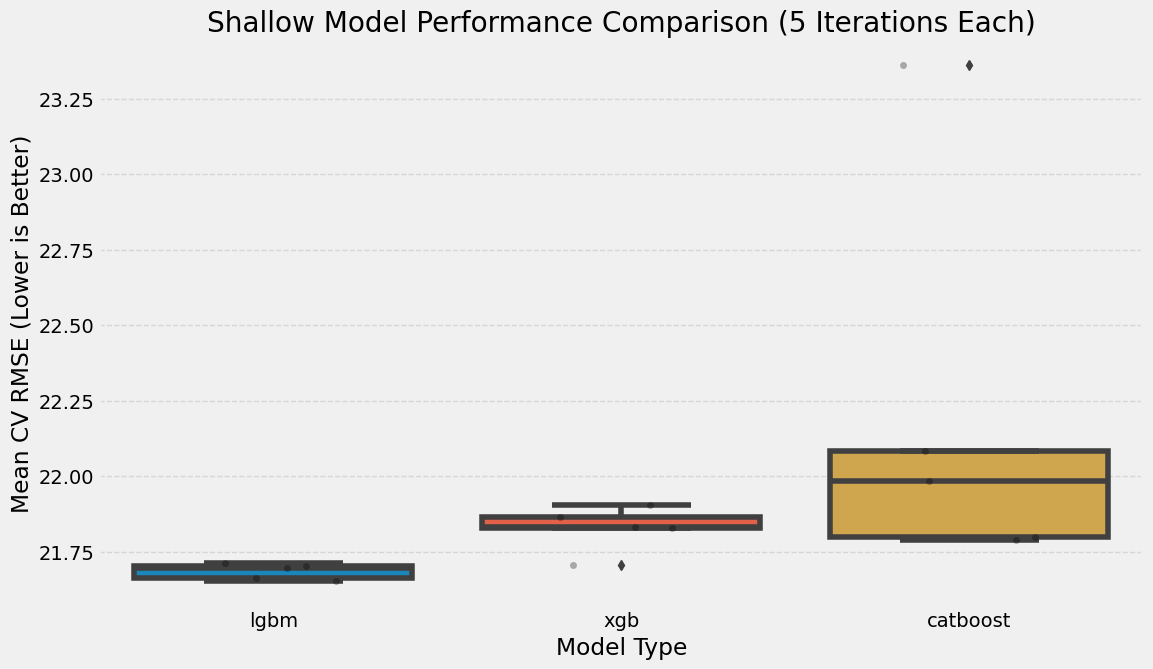


 Best MOdel: LGBM 
Proceeding to Deep Tune (50 iterations) for this model


In [40]:
print("\nStep 10: Analyzing and plotting shallow tune results")

if not shallow_tune_results:
    print("No shallow tuning results to analyze. Exiting.")
else:
    # Convert results to a DataFrame for easier analysis
    results_df = pd.DataFrame(shallow_tune_results)
    
    # Display Best Performance for Each Model
    print("\nBest Shallow Performance by Model Type")
    best_scores = results_df.loc[results_df.groupby('model_type')['mean_rmse'].idxmin()]
    
    # Sort by best RMSE
    best_scores = best_scores.sort_values('mean_rmse')
    
    print(best_scores[['model_type', 'mean_rmse', 'std_rmse', 'mean_r2', 'median_iter']])

    # Plot Graph (Boxplot)
    print("\nGenerating model performance plot...")
    plt.figure(figsize=(12, 7))
    sns.boxplot(data=results_df, x='model_type', y='mean_rmse', 
                order=best_scores['model_type']) # Order boxes by best score
    sns.stripplot(data=results_df, x='model_type', y='mean_rmse', 
                  color='black', alpha=0.3, jitter=0.2,
                  order=best_scores['model_type'])
    plt.title(f'Shallow Model Performance Comparison ({N_ITER_SHALLOW_TUNE} Iterations Each)')
    plt.ylabel('Mean CV RMSE (Lower is Better)')
    plt.xlabel('Model Type')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

    # Choose the Best Overall Model 
    best_overall_shallow = results_df.loc[results_df['mean_rmse'].idxmin()]

    best_model_type = best_overall_shallow['model_type']
    winner_config = model_configs[best_model_type]
    
    print(f"\n Best MOdel: {best_model_type.upper()} ")
    print(f"Proceeding to Deep Tune ({N_ITER_DEEP_TUNE} iterations) for this model")

In [41]:
print(f"\nStep 11: Running DEEP TUNE loop for {best_model_type.upper()}")

deep_tune_results = []

all_params_tried[best_model_type] = set() 
tries = 0
max_tries = N_ITER_DEEP_TUNE * 5 # Use the deep tune config

while len(deep_tune_results) < N_ITER_DEEP_TUNE and tries < max_tries:
    tries += 1
    
    # Sample from the winner's grid
    sampled_params = {k: random.choice(v) for k, v in winner_config['grid'].items()}
    sampled_n_est = random.choice(iter_grid)

    param_key = (tuple(sorted(sampled_params.items())), sampled_n_est)
    if param_key in all_params_tried[best_model_type]:
        continue
    all_params_tried[best_model_type].add(param_key)

    print(f"\n{best_model_type.upper()} DEEP Iter {len(deep_tune_results) + 1}/{N_ITER_DEEP_TUNE} (Attempt {tries})")
    print(f"  Params: {sampled_params}")
    print(f"  n_estimators: {sampled_n_est}")
    
    fold_scores_rmse = []
    fold_scores_r2 = []
    fold_best_iters = []
    
    # Inner CV Loop (for this param set)
    for i, (tr_idx, va_idx) in enumerate(splits):
        Xi_tr, yi_tr = X_labeled.loc[tr_idx].copy(), y_labeled.loc[tr_idx]
        Xi_va_raw, yi_va_raw = X_labeled.loc[va_idx].copy(), y_labeled.loc[va_idx]
        
        Xi_tr['show_date'] = dates_labeled.loc[tr_idx].values
        Xi_va_raw['show_date'] = dates_labeled.loc[va_idx].values
        Xi_tr['book_theater_id'] = labeled_df.loc[tr_idx, 'book_theater_id']
        Xi_va_raw['book_theater_id'] = labeled_df.loc[va_idx, 'book_theater_id']
        
        fit_sample_weight = None
        if USE_RECENCY_WEIGHTING:
            max_dt = Xi_tr.groupby('book_theater_id')['show_date'].transform('max')
            days_back = (max_dt - Xi_tr['show_date']).dt.days
            sw_tr = np.power(0.5, days_back / 28.0) + 0.01
            fit_sample_weight = sw_tr / sw_tr.mean()
        
        va_keep_idx = drop_val_warmup(Xi_va_raw)
        Xi_va = Xi_va_raw.loc[va_keep_idx]; yi_va = yi_va_raw.loc[va_keep_idx]
        
        if len(Xi_va) == 0:
            print(f"  Fold {i+1} Warning: Val set empty after warm-up. Skipping fold."); continue
            
        model_params = winner_config['base_params'].copy()
        model_params.update(sampled_params)
        model_params['n_estimators'] = sampled_n_est
        model = winner_config['model'](**model_params)
        
        fit_args = {}
        # Start with copies
        Xi_tr_features = Xi_tr[features].copy();
        Xi_va_features = Xi_va[features].copy()
        
        if best_model_type == 'lgbm':
            for c in cat_in_use:
                Xi_tr[c] = Xi_tr[c].astype('category'); train_cats = Xi_tr[c].cat.categories
                Xi_va[c] = Xi_va[c].astype(pd.CategoricalDtype(categories=train_cats))
            Xi_tr_features = Xi_tr[features]; Xi_va_features = Xi_va[features] # Re-select
            fit_args = {'eval_set': [(Xi_va_features, yi_va)], 'eval_metric': 'rmse',
                        'callbacks': [lgb.early_stopping(100, verbose=False)],
                        'categorical_feature': cat_in_use}
        elif best_model_type == 'xgb':
            for c in cat_in_use:
                Xi_tr[c] = Xi_tr[c].astype('category'); train_cats = Xi_tr[c].cat.categories
                Xi_va[c] = Xi_va[c].astype(pd.CategoricalDtype(categories=train_cats))
            Xi_tr_features = Xi_tr[features]; Xi_va_features = Xi_va[features] # Re-select
            fit_args = {'eval_set': [(Xi_va_features, yi_va)],
                        'early_stopping_rounds': 100, 'verbose': False}
        elif best_model_type == 'catboost':
            # CatBoost handles raw strings
            fit_args = {'eval_set': [(Xi_va_features, yi_va)], 'early_stopping_rounds': 100,
                        'verbose': False, 'cat_features': cat_in_use}            
            
            Xi_tr_features = Xi_tr_features.fillna(0)
            Xi_va_features = Xi_va_features.fillna(0)
            fit_args = {} 
        
        model.fit(Xi_tr_features, yi_tr, sample_weight=fit_sample_weight, **fit_args)
        
        best_iter = sampled_n_est
        if best_model_type == 'lgbm':
            best_iter = model.best_iteration_ if model.best_iteration_ else sampled_n_est
        elif best_model_type == 'xgb':
            best_iter = model.best_iteration if model.best_iteration else sampled_n_est
        elif best_model_type == 'catboost':
            best_iter = model.best_iteration_ if model.best_iteration_ else sampled_n_est
        
        pred = model.predict(Xi_va_features)
        rmse = mean_squared_error(yi_va, pred, squared=False); r2 = r2_score(yi_va, pred) 
        fold_scores_rmse.append(rmse); fold_scores_r2.append(r2); fold_best_iters.append(best_iter)
    
    if not fold_scores_rmse:
        print("  Iteration skipped: no valid folds."); continue

    mean_rmse = np.mean(fold_scores_rmse); std_rmse = np.std(fold_scores_rmse)
    mean_r2 = np.mean(fold_scores_r2); median_iter = int(np.percentile(fold_best_iters, 50))
    
    print(f"  Avg RMSE: {mean_rmse:.4f} (Std: {std_rmse:.4f}) | Avg R²: {mean_r2:.4f} | Median Iter: {median_iter}")
    
    deep_tune_results.append({
        'model_type': best_model_type, 'params': sampled_params, 'n_est_original': sampled_n_est,
        'mean_rmse': mean_rmse, 'std_rmse': std_rmse, 'mean_r2': mean_r2,
        'median_iter': median_iter,
    })

print("Deep Tuning Loop Complete")


Step 11: Running DEEP TUNE loop for LGBM

LGBM DEEP Iter 1/50 (Attempt 1)
  Params: {'learning_rate': 0.01, 'num_leaves': 31, 'min_child_samples': 80, 'feature_fraction': 0.7, 'bagging_fraction': 0.8, 'lambda_l1': 0.1, 'lambda_l2': 3, 'min_split_gain': 0.2, 'tweedie_variance_power': 1.2}
  n_estimators: 1000
  Avg RMSE: 21.6000 (Std: 2.6770) | Avg R²: 0.5437 | Median Iter: 389

LGBM DEEP Iter 2/50 (Attempt 2)
  Params: {'learning_rate': 0.03, 'num_leaves': 21, 'min_child_samples': 30, 'feature_fraction': 0.8, 'bagging_fraction': 0.7, 'lambda_l1': 0.1, 'lambda_l2': 3, 'min_split_gain': 0.1, 'tweedie_variance_power': 1.1}
  n_estimators: 1000
  Avg RMSE: 21.6893 (Std: 2.7372) | Avg R²: 0.5400 | Median Iter: 126

LGBM DEEP Iter 3/50 (Attempt 3)
  Params: {'learning_rate': 0.03, 'num_leaves': 31, 'min_child_samples': 30, 'feature_fraction': 0.7, 'bagging_fraction': 0.7, 'lambda_l1': 0.1, 'lambda_l2': 0.1, 'min_split_gain': 0.2, 'tweedie_variance_power': 1.4}
  n_estimators: 1000
  Avg RMS

**Select Best Parameters**

In [42]:
print(f"\nStep 12: Final Model Selection from Deep Tune of {best_model_type.upper()}")

if not deep_tune_results:
    print(f"ERROR: Deep tuning for {best_model_type.upper()} produced no results.")
else:
    deep_results_df = pd.DataFrame(deep_tune_results)
    
    # Save the deep tune results
    deep_results_df.to_csv(f"deep_tune_results_{best_model_type}.csv", index=False)
    
    # Find the best run from the deep tune
    best_overall = deep_results_df.loc[deep_results_df['mean_rmse'].idxmin()]

    print("\nFINAL OPTIMIZED MODEL")
    print(f"Model Type: {best_overall['model_type']}")
    print(f"Best Mean CV RMSE: {best_overall['mean_rmse']:.4f}")
    print(f"Best Mean CV R²: {best_overall['mean_r2']:.4f}")
    print(f"Optimal Iterations (Median): {best_overall['median_iter']}")
    print("\nOptimal Parameters:")
    print(best_overall['params'])

    # --- This is the final config for your model ---
    best_params_final = winner_config['base_params'].copy()
    best_params_final.update(best_overall['params'])
    best_params_final['n_estimators'] = best_overall['median_iter'] 
    best_model_type_final = best_overall['model_type']
    
    print(f"\n--- Ready to train final {best_model_type_final} model ---")


Step 12: Final Model Selection from Deep Tune of LGBM

FINAL OPTIMIZED MODEL
Model Type: lgbm
Best Mean CV RMSE: 21.6000
Best Mean CV R²: 0.5437
Optimal Iterations (Median): 389

Optimal Parameters:
{'learning_rate': 0.01, 'num_leaves': 31, 'min_child_samples': 80, 'feature_fraction': 0.7, 'bagging_fraction': 0.8, 'lambda_l1': 0.1, 'lambda_l2': 3, 'min_split_gain': 0.2, 'tweedie_variance_power': 1.2}

--- Ready to train final lgbm model ---


**Final Model Training & Prediction**

In [43]:
print(f"\nStep 13: Training final {best_model_type_final} model on all labeled data...")

# Get all labeled data
X_train_full = full_df.loc[full_df['_is_labeled'] == True, features].copy()
y_train_full = full_df.loc[full_df['_is_labeled'] == True, 'audience_count'].copy()
dates_train_full = full_df.loc[full_df['_is_labeled'] == True, 'show_date'].copy()
X_train_full['book_theater_id'] = labeled_df.loc[full_df['_is_labeled'] == True, 'book_theater_id']
X_train_full['show_date'] = dates_train_full.values

# Get all test data
test_mask = (full_df["_is_kaggle_test"] == True)
X_test = full_df.loc[test_mask, features].copy()
test_lag7_avail = full_df.loc[test_mask, 'lag7_avail'].to_numpy().astype(bool) # For blending
test_keys_out = full_df.loc[test_mask, ["book_theater_id", "show_date"]].copy()

# A/B Test for Recency Weighting
final_fit_sample_weight = None
if USE_RECENCY_WEIGHTING:
    max_dt_final = X_train_full.groupby('book_theater_id')['show_date'].transform('max')
    days_back_final = (max_dt_final - X_train_full['show_date']).dt.days
    sw_final = np.power(0.5, days_back_final / 28.0) + 0.01
    final_fit_sample_weight = sw_final / sw_final.mean()

# Model-Specific Data Prep
# Use the 'winner_config' and 'best_params_final' from the deep tune analysis (Cell 46)
final_model = winner_config['model'](**best_params_final)
final_fit_args = {}

if best_model_type_final == 'lgbm':
    for c in cat_in_use:
        cats = X_train_full[c].astype('category').cat.categories
        X_train_full[c] = X_train_full[c].astype('category')
        if c in X_test.columns:
            X_test[c] = X_test[c].astype(pd.CategoricalDtype(categories=cats))
    final_fit_args = {'categorical_feature': cat_in_use}

elif best_model_type_final == 'xgb':
    for c in cat_in_use:
        cats = X_train_full[c].astype('category').cat.categories
        X_train_full[c] = X_train_full[c].astype('category')
        if c in X_test.columns:
            X_test[c] = X_test[c].astype(pd.CategoricalDtype(categories=cats))
    final_fit_args = {}
    
elif best_model_type_final == 'catboost':
    final_fit_args = {'cat_features': cat_in_use}

# Fit Final Model
print(f"Training final model with n_estimators = {best_params_final['n_estimators']}...")
final_model.fit(X_train_full[features], y_train_full,
                sample_weight=final_fit_sample_weight, 
                **final_fit_args
               )

print("Final model trained. Generating predictions...")

# Generate Predictions 
pred_model = final_model.predict(X_test[features])

# Blend with lag_7 using availability flag
alpha = 0.2
lag7 = X_test['lag_7'].to_numpy() 

predictions = np.where(
    test_lag7_avail, # Use correct availability flag
    (1 - alpha) * pred_model + alpha * lag7, 
    pred_model
)
predictions = np.clip(predictions, 0, None) # Safety clip

pred_df = test_keys_out.assign(audience_count_pred=predictions)
print("Predictions generated and blended.")


Step 13: Training final lgbm model on all labeled data...
Training final model with n_estimators = 389...
Final model trained. Generating predictions...
Predictions generated and blended.


**Create Submission File**

In [44]:
print("\nStep 14: Creating submission file")

# Load sample_submission and merge on keys
sub = pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/sample_submission/sample_submission.csv")
parts = sub["ID"].str.rsplit("_", n=1, expand=True)
sub["book_theater_id"] = parts[0]
sub["show_date"] = pd.to_datetime(parts[1])

sub = sub.merge(
    pred_df,
    on=["book_theater_id", "show_date"],
    how="left",
    validate="one_to_one"
)

unmatched = sub['audience_count_pred'].isna().sum()
if unmatched:
    print(f"--- WARNING: {unmatched} submission rows were not matched. Filling with 0. ---")
    sub['audience_count_pred'] = sub['audience_count_pred'].fillna(0)

sub = sub[["ID", "audience_count_pred"]]
sub.rename(columns={"audience_count_pred": "audience_count"}, inplace=True)

sub.to_csv("submission.csv", index=False)

print("\nSubmission File Created")
print(sub.head())


Step 14: Creating submission file

Submission File Created
                      ID  audience_count
0  book_00001_2024-03-01       33.773895
1  book_00001_2024-03-02       69.687468
2  book_00001_2024-03-03       57.491194
3  book_00001_2024-03-04       20.136492
4  book_00001_2024-03-06       29.639334
